# GRF and belt-speed controller comparison

P1, 1.0 m/s, realistic treadmill. The belt-speed figure compares the optimized trajectory (controller with AP-GRF interpolation) against a one-pass controller replay using the raw AP GRF.

In [32]:
# Configuration: edit these values to change the trial or output styling.
from pathlib import Path
import sys
import seaborn as sns

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "result_HC").is_dir() else cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PARTICIPANT = 1
SPEED = 1.0
RESULT_DIR = ROOT / "result_HC/p1/huntcrossley_6spheres/0814_e300_grf5e3_middleStiff"
RESULT_PATH = RESULT_DIR / "treadmill_real_1_0.pkl"
CONTACT_PATH = RESULT_DIR / "treadmill_real_1_0_contact_diagnostics.csv"
DESIRED_GRF_PATH = ROOT / "data/opensim_exports/p1_grf_mean_speed_1p0.mot"
EXPORT_FIGURES = True

# GRF figure styling
GRF_FIGSIZE = (12, 5.5)
palette = sns.color_palette("mako")
palette2 = sns.color_palette("rocket")
GRF_COLORS = {"fx_r": palette[1], "fy_r": palette[2], "fx_l": palette2[1], "fy_l": palette2[2]}
INTERPOLATION_COLOR = "red"
AXIS_FONTSIZE = 12
TICK_FONTSIZE = 11
LEGEND_FONTSIZE = 9
LEGEND_NCOL = 3
LEGEND_Y = -0.16

# Belt-speed figure styling
BELT_FIGSIZE = (12, 5.5)
BELT_COLORS = {"r": palette[3], "l": palette2[3]}

In [33]:
# Load the saved trajectory, GRFs, references, and controller parameters.
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np

from scripts.plot_grf_belt_noninterpolated_comparison import (
    interpolated_ap_grf,
    load_contact_grfs,
    replay_without_interpolation,
)
from src.gait_data import DEFAULT_GAIT_DATA_FILE
from visualize_walking2d import (
    get_treadmill_controller_metadata,
    load_desired_belt_speed,
    load_desired_grf,
)

with RESULT_PATH.open("rb") as handle:
    ((states, globals_), _info, settings) = cloudpickle.load(handle)

treadmill_states = np.asarray(states.gc_model, dtype=float)
n_nodes = treadmill_states.shape[0]
nodes = np.arange(n_nodes)
grf = load_contact_grfs(CONTACT_PATH, n_nodes)
desired_grf = load_desired_grf(str(DESIRED_GRF_PATH), n_nodes)
gait_data_path = Path(DEFAULT_GAIT_DATA_FILE)
if not gait_data_path.is_absolute():
    gait_data_path = ROOT / gait_data_path
desired_belt = load_desired_belt_speed(
    str(gait_data_path), PARTICIPANT, SPEED, n_nodes
)
metadata = get_treadmill_controller_metadata(settings).copy()
metadata["dt"] = float(globals_.dur) / (n_nodes - 1)
default_samples = int(metadata.get("post_hs_interpolation_samples", 0))
side_metadata = {
    "r": {
        "heel_strike_index": int(metadata.get("heel_strike_index_r", 0)),
        "interpolation_samples": int(metadata.get("post_hs_interpolation_samples_r", default_samples)),
    },
    "l": {
        "heel_strike_index": int(metadata.get("heel_strike_index_l", (n_nodes - 1) // 2)),
        "interpolation_samples": int(metadata.get("post_hs_interpolation_samples_l", default_samples)),
    },
}
metadata

{'delay': 4,
 'error_delay_samples': 1,
 'k_fy': 9.263142150735485e-07,
 'k_fx': -4.143226567605244e-06,
 'k_p': 0.6539355723181786,
 'k_d': 1.2842889273485065e-16,
 'post_hs_interpolation_samples': 4,
 'ap_grf_filter_enabled': False,
 'heel_strike_index_r': 99,
 'heel_strike_index_l': 48,
 'post_hs_interpolation_samples_r': 5,
 'post_hs_interpolation_samples_l': 6,
 'controller_edge_source_file': '/home/rzlin/ys64ofuj/ideal-treadmill-biosym/result_HC/p1/huntcrossley_6spheres/0814_lowE/treadmill_fixed_1_0_contact_diagnostics.csv',
 'target_speed': np.float64(-1.0),
 'swing_force_threshold': 10.0,
 'dt': 0.010657039765519759}

## Ground-reaction forces

The purple curves are drawn only over the nodes replaced by interpolation.

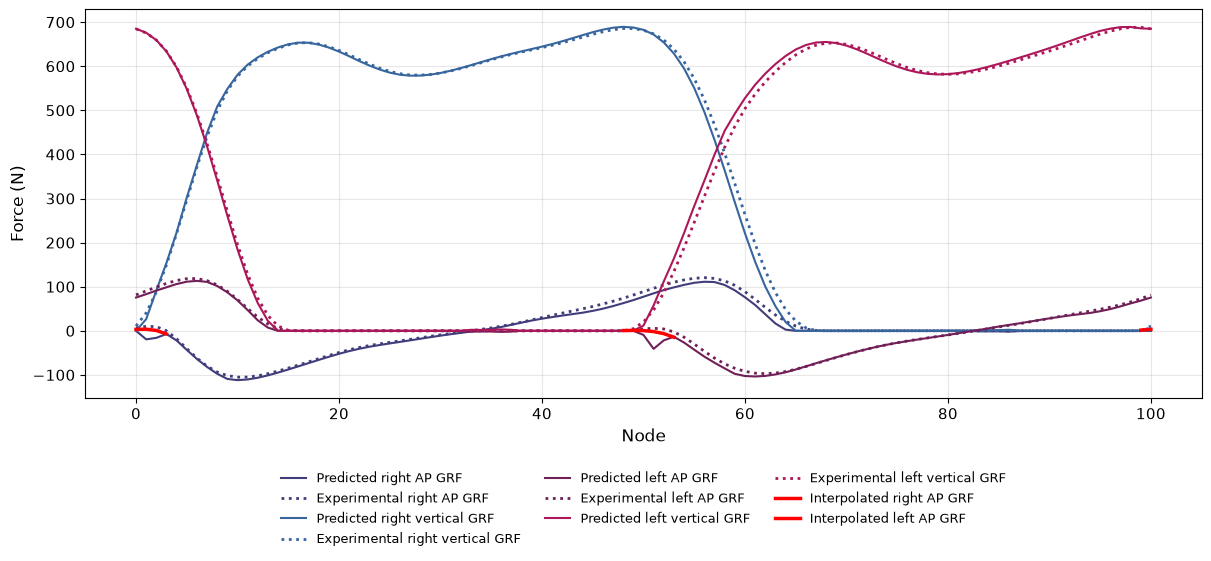

In [34]:
fig_grf, ax = plt.subplots(figsize=GRF_FIGSIZE, constrained_layout=True)
labels = {
    "fx_r": "Predicted right AP GRF",
    "fy_r": "Predicted right vertical GRF",
    "fx_l": "Predicted left AP GRF",
    "fy_l": "Predicted left vertical GRF",
}
desired_keys = {
    "fx_r": "grf_x_r", "fy_r": "grf_y_r",
    "fx_l": "grf_x_l", "fy_l": "grf_y_l",
}
for key in labels:
    ax.plot(nodes, grf[key], color=GRF_COLORS[key], label=labels[key])
    ax.plot(
        nodes, desired_grf[desired_keys[key]], color=GRF_COLORS[key],
        linestyle=":", linewidth=2,
        label=labels[key].replace("Predicted", "Experimental"),
    )

for side, side_name, linestyle in (("r", "right", "-"), ("l", "left", "-")):
    info = side_metadata[side]
    interpolated = interpolated_ap_grf(
        grf[f"fx_{side}"], info["heel_strike_index"], info["interpolation_samples"]
    )
    replaced_nodes = (
        info["heel_strike_index"] + np.arange(info["interpolation_samples"])
    ) % (n_nodes - 1)
    interpolation_only = np.full(n_nodes, np.nan)
    interpolation_only[replaced_nodes] = interpolated[replaced_nodes]
    if 0 in replaced_nodes:
        interpolation_only[-1] = interpolated[-1]
    ax.plot(
        nodes, interpolation_only, color=INTERPOLATION_COLOR,
        linestyle=linestyle, linewidth=2.5,
        label=f"Interpolated {side_name} AP GRF",
    )

ax.set_xlabel("Node", fontsize=AXIS_FONTSIZE)
ax.set_ylabel("Force (N)", fontsize=AXIS_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.grid(True, alpha=0.3)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, LEGEND_Y),
    ncol=LEGEND_NCOL, fontsize=LEGEND_FONTSIZE, frameon=False,
)
if EXPORT_FIGURES:
    fig_grf.savefig(RESULT_DIR / "treadmill_real_1_0_grf.png", dpi=200, bbox_inches="tight")
    fig_grf.savefig(RESULT_DIR / "treadmill_real_1_0_grf.pdf", bbox_inches="tight")
plt.show()

## Belt speeds

Dashed curves are the one-pass controller predictions with AP interpolation disabled.

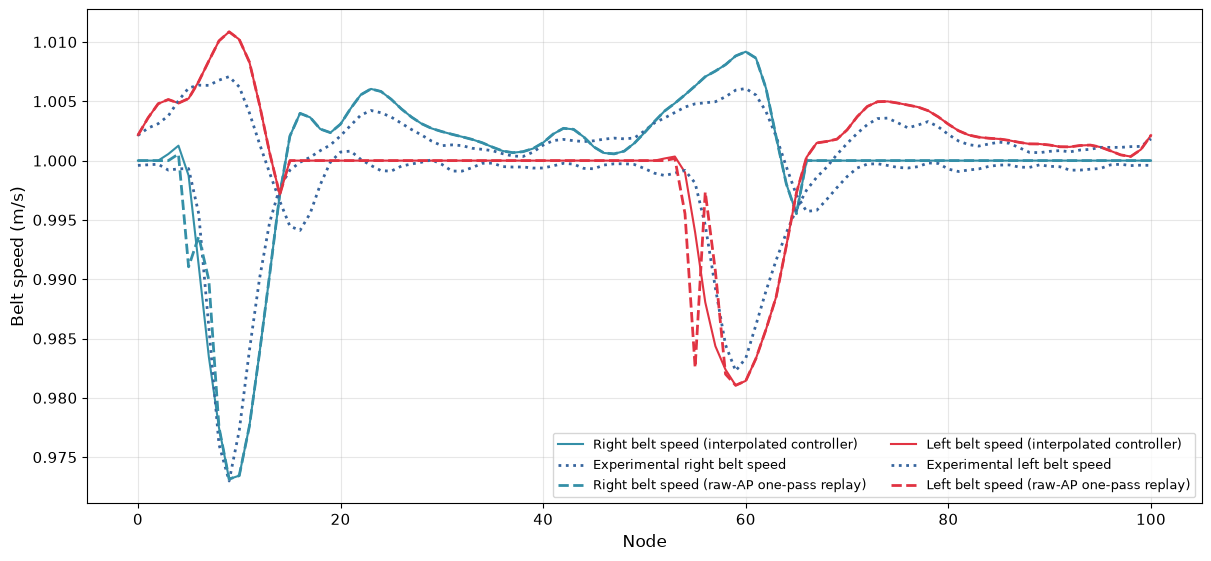

In [39]:
replay = {
    "r": replay_without_interpolation(
        fy=grf["fy_r"], fx=grf["fx_r"], speed=treadmill_states[:, 0], metadata=metadata
    ),
    "l": replay_without_interpolation(
        fy=grf["fy_l"], fx=grf["fx_l"], speed=treadmill_states[:, 1], metadata=metadata
    ),
}

fig_belt, ax = plt.subplots(figsize=BELT_FIGSIZE, constrained_layout=True)
for column, side, side_name in ((0, "r", "Right"), (1, "l", "Left")):
    color = BELT_COLORS[side]
    ax.plot(
        nodes, -treadmill_states[:, column], color=color,
        label=f"{side_name} belt speed (interpolated controller)",
    )
    ax.plot(
        nodes, desired_belt[side_name.lower()], color=palette[2], linestyle=":", linewidth=2,
        label=f"Experimental {side_name.lower()} belt speed",
    )
    ax.plot(
        nodes, -replay[side], color=color, linestyle="--", linewidth=2,
        label=f"{side_name} belt speed (raw-AP one-pass replay)",
    )
ax.set_xlabel("Node", fontsize=AXIS_FONTSIZE)
ax.set_ylabel("Belt speed (m/s)", fontsize=AXIS_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=LEGEND_FONTSIZE)
if EXPORT_FIGURES:
    fig_belt.savefig(RESULT_DIR / "treadmill_real_1_0_belt_speed_comparison.png", dpi=200, bbox_inches="tight")
    fig_belt.savefig(RESULT_DIR / "treadmill_real_1_0_belt_speed_comparison.pdf", bbox_inches="tight")
plt.show()